In [1]:
import pandas as pd

df = pd.read_csv("data/career_market_panel.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Shape: (140, 42)

Columns:
['ID', 'LAST_UPDATED_DATE', 'POSTED', 'EXPIRED', 'TITLE_RAW', 'BODY', 'COMPANY_NAME', 'EDUCATION_LEVELS_NAME', 'MIN_YEARS_EXPERIENCE', 'MAX_YEARS_EXPERIENCE', 'SALARY', 'REMOTE_TYPE', 'REMOTE_TYPE_NAME', 'ORIGINAL_PAY_PERIOD', 'SALARY_TO', 'SALARY_FROM', 'LOCATION', 'CITY_NAME', 'STATE_NAME', 'NAICS3', 'NAICS3_NAME', 'TITLE', 'TITLE_NAME', 'TITLE_CLEAN', 'SKILLS', 'SKILLS_NAME', 'SPECIALIZED_SKILLS', 'SPECIALIZED_SKILLS_NAME', 'COMMON_SKILLS', 'COMMON_SKILLS_NAME', 'SOFTWARE_SKILLS', 'SOFTWARE_SKILLS_NAME', 'ONET', 'ONET_NAME', 'SOC_2021_5', 'SOC_2021_5_NAME', 'remote_status', 'city_clean', 'state_clean', 'salary_midpoint', 'industry_scope', 'career_scope']


,ID,LAST_UPDATED_DATE,POSTED,EXPIRED,TITLE_RAW,BODY,COMPANY_NAME,EDUCATION_LEVELS_NAME,MIN_YEARS_EXPERIENCE,MAX_YEARS_EXPERIENCE,...,ONET,ONET_NAME,SOC_2021_5,SOC_2021_5_NAME,remote_status,city_clean,state_clean,salary_midpoint,industry_scope,career_scope
0,0157c403b9d6c4de322cf7e311ba4f1fb119b802,2024-10-09,2024-07-09,2024-07-24,Data Analyst II,Data Analyst II Risk Solutions - 5.0 Alpharett...,Risk Solutions,"[\r\n ""Bachelor's degree""\r\n]",NaN,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Unknown,"Alpharetta, GA",Georgia,NaN,NAICS 523,Core Data Analyst
1,6273f8cf57a3df15b8a5d04b3a34704259112e43,2024-08-12,2024-06-11,2024-07-04,Product Data Analyst,Alternate Locations: Work from Home; Fort Wayn...,Lincoln Financial Group,"[\r\n ""Bachelor's degree""\r\n]",5.0,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Remote,"Helena, MT",Montana,93850.0,NAICS 523,Core Data Analyst
2,acf1a5b458391432d29a4a6b46dac9fec0f0597d,2024-08-12,2024-06-11,2024-07-04,Product Data Analyst,Alternate Locations: Work from Home; Fort Wayn...,Lincoln Financial Group,"[\r\n ""Bachelor's degree""\r\n]",5.0,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Remote,"Jackson, MS",Mississippi,93850.0,NAICS 523,Core Data Analyst
3,128f78581c818bee4f9c2bdcfc198179b74e5bc0,2024-08-12,2024-06-11,2024-07-04,Product Data Analyst,Alternate Locations: Work from Home; Fort Wayn...,Lincoln Financial Group,"[\r\n ""Bachelor's degree""\r\n]",5.0,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Remote,"Salt Lake City, UT",Utah,93850.0,NAICS 523,Core Data Analyst
4,9f6971aad7e610e1b07b3f5628e4e2366da50699,2024-09-06,2024-05-30,2024-06-10,CW- Data Analyst II,"CW- Data Analyst II 3.7 out of 5 Charlotte, NC...",TIAA,"[\r\n ""No Education Listed""\r\n]",NaN,NaN,...,15-2051.01,Business Intelligence Analysts,15-2051,Data Scientists,Unknown,"Charlotte, NC",North Carolina,91343.5,NAICS 523,Core Data Analyst


In [2]:
skill_cols = [
    "SKILLS_NAME",
    "SPECIALIZED_SKILLS_NAME",
    "COMMON_SKILLS_NAME",
    "SOFTWARE_SKILLS_NAME"
]

for col in skill_cols:
    print(f"\n--- {col} ---")
    print(df[col].head(10).to_string())


--- SKILLS_NAME ---
0    [\r\n  "Power BI",\r\n  "Management",\r\n  "Mi...
1    [\r\n  "Project Portfolio Management",\r\n  "M...
2    [\r\n  "Project Portfolio Management",\r\n  "M...
3    [\r\n  "Project Portfolio Management",\r\n  "M...
4    [\r\n  "Research",\r\n  "Data Analysis",\r\n  ...
5    [\r\n  "Project Portfolio Management",\r\n  "M...
6    [\r\n  "Debugging",\r\n  "Angular (Web Framewo...
7    [\r\n  "Project Portfolio Management",\r\n  "M...
8    [\r\n  "Project Portfolio Management",\r\n  "M...
9    [\r\n  "Research",\r\n  "Information Technolog...

--- SPECIALIZED_SKILLS_NAME ---
0    [\r\n  "Power BI",\r\n  "Microsoft Azure",\r\n...
1    [\r\n  "Project Portfolio Management",\r\n  "F...
2    [\r\n  "Project Portfolio Management",\r\n  "F...
3    [\r\n  "Project Portfolio Management",\r\n  "F...
4    [\r\n  "Data Analysis",\r\n  "Corporate Financ...
5    [\r\n  "Project Portfolio Management",\r\n  "P...
6    [\r\n  "Debugging",\r\n  "Angular (Web Framewo...
7    [\r\n 

In [3]:
import json
import pandas as pd

def parse_skill_list(value):
    if pd.isna(value):
        return []
    
    if isinstance(value, list):
        return value
    
    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except (json.JSONDecodeError, TypeError):
        return []

for col in skill_cols:
    df[f"{col}_parsed"] = df[col].apply(parse_skill_list)

for col in skill_cols:
    print(f"\n--- {col} ---")
    print(df[f"{col}_parsed"].head())


--- SKILLS_NAME ---
0    [Power BI, Management, Microsoft Azure, Proble...
1    [Project Portfolio Management, Management, Fun...
2    [Project Portfolio Management, Management, Fun...
3    [Project Portfolio Management, Management, Fun...
4    [Research, Data Analysis, Corporate Finance, D...
Name: SKILLS_NAME_parsed, dtype: object

--- SPECIALIZED_SKILLS_NAME ---
0    [Power BI, Microsoft Azure, Operational Effici...
1    [Project Portfolio Management, Fundraising, Pr...
2    [Project Portfolio Management, Fundraising, Pr...
3    [Project Portfolio Management, Fundraising, Pr...
4    [Data Analysis, Corporate Finance, Data Mining...
Name: SPECIALIZED_SKILLS_NAME_parsed, dtype: object

--- COMMON_SKILLS_NAME ---
0    [Management, Problem Solving, Communication, M...
1    [Management, Influencing Skills, Communication...
2    [Management, Influencing Skills, Communication...
3    [Management, Influencing Skills, Communication...
4             [Research, Decision Making, Mathematics]
N

In [4]:
for col in skill_cols:
    parsed_col = f"{col}_parsed"
    
    print(
        col,
        "Non-empty rows:",
        df[parsed_col].apply(len).gt(0).sum()
    )

SKILLS_NAME Non-empty rows: 140
SPECIALIZED_SKILLS_NAME Non-empty rows: 140
COMMON_SKILLS_NAME Non-empty rows: 135
SOFTWARE_SKILLS_NAME Non-empty rows: 130


In [5]:
from collections import Counter
import pandas as pd

skill_counter = Counter()

for skills in df["SKILLS_NAME_parsed"]:
    # Each skill counts at most once per job posting
    skill_counter.update(set(skills))

top_skills = pd.DataFrame(
    skill_counter.most_common(20),
    columns=["Skill", "Job_Count"]
)

top_skills["Demand_Percent"] = (
    top_skills["Job_Count"] / len(df) * 100
).round(1)

top_skills

,Skill,Job_Count,Demand_Percent
0,Data Analysis,97,69.3
1,Communication,85,60.7
2,Management,80,57.1
3,Tableau (Business Intelligence Software),78,55.7
4,SQL (Programming Language),70,50.0
5,Influencing Skills,55,39.3
6,Python (Programming Language),52,37.1
7,Sales,51,36.4
8,New Product Development,47,33.6
9,Visual Basic For Applications,46,32.9


In [6]:
team_skills = pd.DataFrame({
    "Skill": [
        "Python",
        "SQL",
        "Excel",
        "Power BI / Tableau",
        "R",
        "Statistics",
        "Data Visualization",
        "Machine Learning",
        "PySpark / Big Data",
        "AWS / Cloud",
        "Data Cleaning",
        "Business Analysis"
    ],
    "Taiqi": [3, 3, 4, 4, 3, 3, 4, 2, 2, 2, 3, 4],
    "Joseph": [2, 2, 4, 3, 3, 4, 4, 3, 2, 2, 3, 4],
    "Igor": [2, 2, 5, 3, 3, 4, 4, 2, 3, 3, 4, 5]
})

team_skills

,Skill,Taiqi,Joseph,Igor
0,Python,3,2,2
1,SQL,3,2,2
2,Excel,4,4,5
3,Power BI / Tableau,4,3,3
4,R,3,3,3
5,Statistics,3,4,4
6,Data Visualization,4,4,4
7,Machine Learning,2,3,2
8,PySpark / Big Data,2,2,3
9,AWS / Cloud,2,2,3


In [7]:
team_skills["Team_Average"] = (
    team_skills[["Taiqi", "Joseph", "Igor"]]
    .mean(axis=1)
    .round(2)
)

team_skills

,Skill,Taiqi,Joseph,Igor,Team_Average
0,Python,3,2,2,2.33
1,SQL,3,2,2,2.33
2,Excel,4,4,5,4.33
3,Power BI / Tableau,4,3,3,3.33
4,R,3,3,3,3.00
5,Statistics,3,4,4,3.67
6,Data Visualization,4,4,4,4.00
7,Machine Learning,2,3,2,2.33
8,PySpark / Big Data,2,2,3,2.33
9,AWS / Cloud,2,2,3,2.33


In [8]:
target_skills = [
    "Data Analysis",
    "Communication",
    "SQL (Programming Language)",
    "Python (Programming Language)",
    "Tableau (Business Intelligence Software)",
    "Microsoft Excel",
    "Statistics",
    "Data Visualization",
    "Machine Learning",
    "Amazon Web Services",
    "Business Analysis"
]

target_results = []

for skill in target_skills:
    count = sum(
        skill in skills
        for skills in df["SKILLS_NAME_parsed"]
    )

    target_results.append({
        "Skill": skill,
        "Job_Count": count,
        "Demand_Percent": round(count / len(df) * 100, 1)
    })

target_skill_demand = pd.DataFrame(target_results)

target_skill_demand

,Skill,Job_Count,Demand_Percent
0,Data Analysis,97,69.3
1,Communication,85,60.7
2,SQL (Programming Language),70,50.0
3,Python (Programming Language),52,37.1
4,Tableau (Business Intelligence Software),78,55.7
5,Microsoft Excel,33,23.6
6,Statistics,15,10.7
7,Data Visualization,27,19.3
8,Machine Learning,13,9.3
9,Amazon Web Services,10,7.1


In [11]:
market_team_map = {
    "Python (Programming Language)": "Python",
    "SQL (Programming Language)": "SQL",
    "Microsoft Excel": "Excel",
    "Tableau (Business Intelligence Software)": "Power BI / Tableau",
    "Statistics": "Statistics",
    "Data Visualization": "Data Visualization",
    "Machine Learning": "Machine Learning",
    "Amazon Web Services": "AWS / Cloud"
}

In [12]:
market_compare = target_skill_demand[
    target_skill_demand["Skill"].isin(market_team_map.keys())
].copy()

market_compare["Skill"] = market_compare["Skill"].map(market_team_map)

market_compare

,Skill,Job_Count,Demand_Percent
2,SQL,70,50.0
3,Python,52,37.1
4,Power BI / Tableau,78,55.7
5,Excel,33,23.6
6,Statistics,15,10.7
7,Data Visualization,27,19.3
8,Machine Learning,13,9.3
9,AWS / Cloud,10,7.1


In [15]:
comparison = market_compare.merge(
    team_skills[["Skill", "Team_Average"]],
    on="Skill",
    how="left"
)

comparison["Team_Skill_Percent"] = (
    comparison["Team_Average"] / 5 * 100
).round(1)

comparison

,Skill,Job_Count,Demand_Percent,Team_Average,Team_Skill_Percent
0,SQL,70,50.0,2.33,46.6
1,Python,52,37.1,2.33,46.6
2,Power BI / Tableau,78,55.7,3.33,66.6
3,Excel,33,23.6,4.33,86.6
4,Statistics,15,10.7,3.67,73.4
5,Data Visualization,27,19.3,4.00,80.0
6,Machine Learning,13,9.3,2.33,46.6
7,AWS / Cloud,10,7.1,2.33,46.6


In [16]:
comparison["Gap"] = (
    comparison["Demand_Percent"] - comparison["Team_Skill_Percent"]
).round(1)

comparison.sort_values("Gap", ascending=False)

,Skill,Job_Count,Demand_Percent,Team_Average,Team_Skill_Percent,Gap
0,SQL,70,50.0,2.33,46.6,3.4
1,Python,52,37.1,2.33,46.6,-9.5
2,Power BI / Tableau,78,55.7,3.33,66.6,-10.9
6,Machine Learning,13,9.3,2.33,46.6,-37.3
7,AWS / Cloud,10,7.1,2.33,46.6,-39.5
5,Data Visualization,27,19.3,4.00,80.0,-60.7
4,Statistics,15,10.7,3.67,73.4,-62.7
3,Excel,33,23.6,4.33,86.6,-63.0


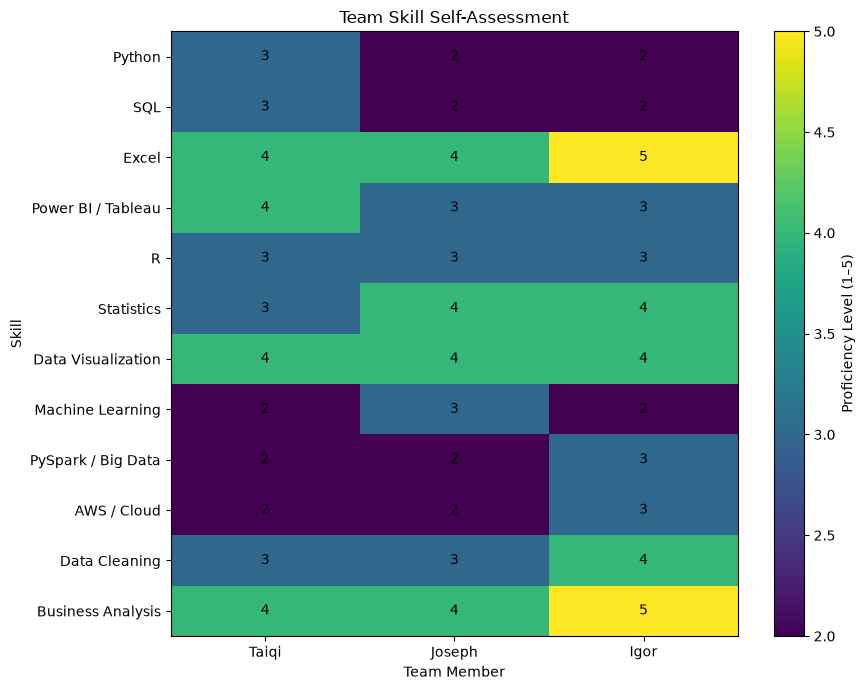

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap_data = team_skills.set_index("Skill")[["Taiqi", "Joseph", "Igor"]]

fig, ax = plt.subplots(figsize=(9, 7))

im = ax.imshow(heatmap_data.values, aspect="auto")

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.0f}",
            ha="center",
            va="center"
        )

ax.set_title("Team Skill Self-Assessment")
ax.set_xlabel("Team Member")
ax.set_ylabel("Skill")

fig.colorbar(im, ax=ax, label="Proficiency Level (1–5)")

plt.tight_layout()
plt.savefig("figures/team_skill_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

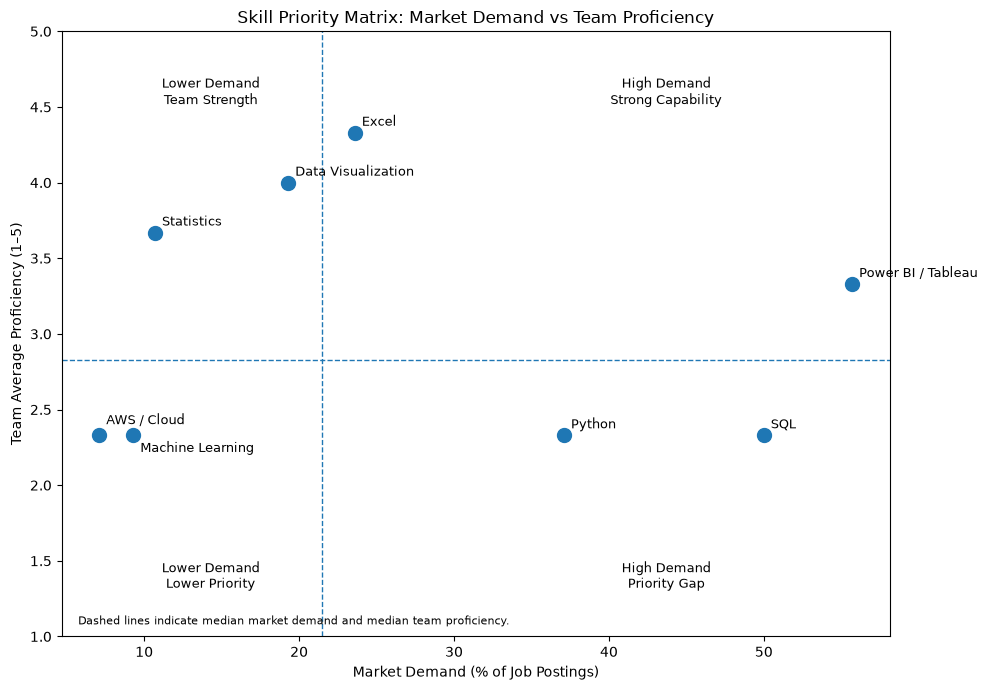

Median market demand: 21.5%
Median team proficiency: 2.83


In [20]:
import matplotlib.pyplot as plt

# Copy the comparison dataframe
priority_data = comparison.copy()

# Sort for cleaner processing
priority_data = priority_data.sort_values(
    "Demand_Percent",
    ascending=True
)

# Create figure
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter plot
ax.scatter(
    priority_data["Demand_Percent"],
    priority_data["Team_Average"],
    s=100
)

# Custom label offsets to avoid overlap
label_offsets = {
    "AWS / Cloud": (5, 8),
    "Machine Learning": (5, -12),
    "Statistics": (5, 5),
    "Data Visualization": (5, 5),
    "Excel": (5, 5),
    "Python": (5, 5),
    "SQL": (5, 5),
    "Power BI / Tableau": (5, 5)
}

# Add labels
for _, row in priority_data.iterrows():
    offset = label_offsets.get(row["Skill"], (5, 5))

    ax.annotate(
        row["Skill"],
        (row["Demand_Percent"], row["Team_Average"]),
        xytext=offset,
        textcoords="offset points",
        fontsize=9
    )

# Calculate median reference values
median_demand = priority_data["Demand_Percent"].median()
median_proficiency = priority_data["Team_Average"].median()

# Add reference lines
ax.axvline(
    median_demand,
    linestyle="--",
    linewidth=1
)

ax.axhline(
    median_proficiency,
    linestyle="--",
    linewidth=1
)

# Axis labels and title
ax.set_xlabel("Market Demand (% of Job Postings)")
ax.set_ylabel("Team Average Proficiency (1–5)")
ax.set_title(
    "Skill Priority Matrix: Market Demand vs Team Proficiency"
)

# Keep proficiency scale aligned with the 1–5 assessment
ax.set_ylim(1, 5)

# Add explanation for dashed lines
ax.text(
    0.02,
    0.02,
    (
        "Dashed lines indicate median market demand "
        "and median team proficiency."
    ),
    transform=ax.transAxes,
    fontsize=8
)

# Optional quadrant labels
ax.text(
    0.73,
    0.90,
    "High Demand\nStrong Capability",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    0.73,
    0.10,
    "High Demand\nPriority Gap",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    0.18,
    0.90,
    "Lower Demand\nTeam Strength",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=9
)

ax.text(
    0.18,
    0.10,
    "Lower Demand\nLower Priority",
    transform=ax.transAxes,
    ha="center",
    va="center",
    fontsize=9
)

# Improve spacing
plt.tight_layout()

# Save figure for Quarto website
plt.savefig(
    "figures/skill_priority_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Print reference values for interpretation
print(f"Median market demand: {median_demand:.1f}%")
print(f"Median team proficiency: {median_proficiency:.2f}")

In [21]:
# Skills that are directly comparable between the market data
# and the team self-assessment
comparable_skills = {
    "Python": "Python",
    "SQL": "SQL",
    "Excel": "Excel",
    "Power BI / Tableau": "Power BI / Tableau",
    "Statistics": "Statistics",
    "Data Visualization": "Data Visualization",
    "Machine Learning": "Machine Learning",
    "AWS / Cloud": "AWS / Cloud"
}

# Create a lookup table for market demand
market_lookup = comparison.set_index("Skill")["Demand_Percent"].to_dict()

members = ["Taiqi", "Joseph", "Igor"]

individual_gap_rows = []

for member in members:
    for skill in comparable_skills:
        market_demand = market_lookup.get(skill)
        proficiency = team_skills.loc[
            team_skills["Skill"] == skill,
            member
        ].iloc[0]

        individual_gap_rows.append({
            "Member": member,
            "Skill": skill,
            "Market_Demand_Percent": market_demand,
            "Proficiency": proficiency
        })

individual_gaps = pd.DataFrame(individual_gap_rows)

individual_gaps

,Member,Skill,Market_Demand_Percent,Proficiency
0,Taiqi,Python,37.1,3
1,Taiqi,SQL,50.0,3
2,Taiqi,Excel,23.6,4
3,Taiqi,Power BI / Tableau,55.7,4
4,Taiqi,Statistics,10.7,3
5,Taiqi,Data Visualization,19.3,4
6,Taiqi,Machine Learning,9.3,2
7,Taiqi,AWS / Cloud,7.1,2
8,Joseph,Python,37.1,2
9,Joseph,SQL,50.0,2


In [22]:
top_priorities = (
    individual_gaps
    .groupby("Member", group_keys=False)
    .head(3)
)

top_priorities

,Member,Skill,Market_Demand_Percent,Proficiency
0,Taiqi,Python,37.1,3
1,Taiqi,SQL,50.0,3
2,Taiqi,Excel,23.6,4
8,Joseph,Python,37.1,2
9,Joseph,SQL,50.0,2
10,Joseph,Excel,23.6,4
16,Igor,Python,37.1,2
17,Igor,SQL,50.0,2
18,Igor,Excel,23.6,5


In [25]:
# Create intuitive priority labels instead of showing a raw priority score

def priority_label(demand, proficiency):
    if demand >= 35 and proficiency <= 3:
        return "High Priority"
    elif demand >= 20 and proficiency <= 4:
        return "Medium Priority"
    else:
        return "Lower Priority"


individual_gaps["Priority"] = individual_gaps.apply(
    lambda row: priority_label(
        row["Market_Demand_Percent"],
        row["Proficiency"]
    ),
    axis=1
)

# Set an order so High Priority appears first
priority_order = {
    "High Priority": 1,
    "Medium Priority": 2,
    "Lower Priority": 3
}

individual_gaps["Priority_Order"] = (
    individual_gaps["Priority"].map(priority_order)
)

# Sort by member, priority level, then market demand
priority_summary = (
    individual_gaps[
        [
            "Member",
            "Skill",
            "Market_Demand_Percent",
            "Proficiency",
            "Priority",
            "Priority_Order"
        ]
    ]
    .sort_values(
        [
            "Member",
            "Priority_Order",
            "Market_Demand_Percent"
        ],
        ascending=[True, True, False]
    )
    .drop(columns="Priority_Order")
    .reset_index(drop=True)
)

# Make market demand easier to read
priority_summary["Market_Demand_Percent"] = (
    priority_summary["Market_Demand_Percent"]
    .round(1)
)

priority_summary

,Member,Skill,Market_Demand_Percent,Proficiency,Priority
0,Igor,Power BI / Tableau,55.7,3,High Priority
1,Igor,SQL,50.0,2,High Priority
2,Igor,Python,37.1,2,High Priority
3,Igor,Excel,23.6,5,Lower Priority
4,Igor,Data Visualization,19.3,4,Lower Priority
5,Igor,Statistics,10.7,4,Lower Priority
6,Igor,Machine Learning,9.3,2,Lower Priority
7,Igor,AWS / Cloud,7.1,3,Lower Priority
8,Joseph,Power BI / Tableau,55.7,3,High Priority
9,Joseph,SQL,50.0,2,High Priority


In [26]:
priority_focus = priority_summary[
    priority_summary["Priority"].isin(
        ["High Priority", "Medium Priority"]
    )
]

priority_focus

,Member,Skill,Market_Demand_Percent,Proficiency,Priority
0,Igor,Power BI / Tableau,55.7,3,High Priority
1,Igor,SQL,50.0,2,High Priority
2,Igor,Python,37.1,2,High Priority
8,Joseph,Power BI / Tableau,55.7,3,High Priority
9,Joseph,SQL,50.0,2,High Priority
10,Joseph,Python,37.1,2,High Priority
11,Joseph,Excel,23.6,4,Medium Priority
16,Taiqi,SQL,50.0,3,High Priority
17,Taiqi,Python,37.1,3,High Priority
18,Taiqi,Power BI / Tableau,55.7,4,Medium Priority


In [27]:
for member in ["Taiqi", "Joseph", "Igor"]:
    print(f"\n--- {member} ---")
    display(
        priority_focus[
            priority_focus["Member"] == member
        ]
    )


--- Taiqi ---


,Member,Skill,Market_Demand_Percent,Proficiency,Priority
16,Taiqi,SQL,50.0,3,High Priority
17,Taiqi,Python,37.1,3,High Priority
18,Taiqi,Power BI / Tableau,55.7,4,Medium Priority
19,Taiqi,Excel,23.6,4,Medium Priority



--- Joseph ---


,Member,Skill,Market_Demand_Percent,Proficiency,Priority
8,Joseph,Power BI / Tableau,55.7,3,High Priority
9,Joseph,SQL,50.0,2,High Priority
10,Joseph,Python,37.1,2,High Priority
11,Joseph,Excel,23.6,4,Medium Priority



--- Igor ---


,Member,Skill,Market_Demand_Percent,Proficiency,Priority
0,Igor,Power BI / Tableau,55.7,3,High Priority
1,Igor,SQL,50.0,2,High Priority
2,Igor,Python,37.1,2,High Priority


In [28]:
learning_resources = {
    "SQL": "Practice joins, CTEs, window functions, and analytical SQL using SQLBolt, LeetCode SQL, or course exercises.",
    "Python": "Strengthen pandas, data cleaning, visualization, and automation through applied notebook projects.",
    "Power BI / Tableau": "Build interactive dashboards and practice calculated fields, filters, drill-downs, and storytelling.",
    "Excel": "Improve advanced formulas, PivotTables, Power Query, and data modeling.",
    "Statistics": "Review hypothesis testing, regression, probability, and interpretation of statistical outputs.",
    "Data Visualization": "Practice chart selection, dashboard design, and communicating insights clearly.",
    "Machine Learning": "Focus on regression, classification, clustering, model evaluation, and practical scikit-learn workflows.",
    "AWS / Cloud": "Practice cloud storage, compute, and data workflows using AWS learning labs and small projects."
}

improvement_plan_rows = []

for _, row in priority_focus.iterrows():
    improvement_plan_rows.append({
        "Member": row["Member"],
        "Skill": row["Skill"],
        "Priority": row["Priority"],
        "Market_Demand_Percent": row["Market_Demand_Percent"],
        "Current_Proficiency": row["Proficiency"],
        "Recommended_Action": learning_resources.get(
            row["Skill"],
            "Continue building practical experience through projects and targeted practice."
        )
    })

improvement_plan = pd.DataFrame(improvement_plan_rows)

improvement_plan

,Member,Skill,Priority,Market_Demand_Percent,Current_Proficiency,Recommended_Action
0,Igor,Power BI / Tableau,High Priority,55.7,3,Build interactive dashboards and practice calc...
1,Igor,SQL,High Priority,50.0,2,"Practice joins, CTEs, window functions, and an..."
2,Igor,Python,High Priority,37.1,2,"Strengthen pandas, data cleaning, visualizatio..."
3,Joseph,Power BI / Tableau,High Priority,55.7,3,Build interactive dashboards and practice calc...
4,Joseph,SQL,High Priority,50.0,2,"Practice joins, CTEs, window functions, and an..."
5,Joseph,Python,High Priority,37.1,2,"Strengthen pandas, data cleaning, visualizatio..."
6,Joseph,Excel,Medium Priority,23.6,4,"Improve advanced formulas, PivotTables, Power ..."
7,Taiqi,SQL,High Priority,50.0,3,"Practice joins, CTEs, window functions, and an..."
8,Taiqi,Python,High Priority,37.1,3,"Strengthen pandas, data cleaning, visualizatio..."
9,Taiqi,Power BI / Tableau,Medium Priority,55.7,4,Build interactive dashboards and practice calc...
